# Subplate thickness analysis

Whole-brain mean thickness = mean Euclidean distance between corresponding vertices of the WM surface (`*.wm..obj`, outer SP) and inner SP surface (`*.innersp.obj`), after applying `recon_native.xfm` so values are in native mm.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/thickness_audit.csv')
df = df.dropna(subset=['wholebrain_thk_mean']).copy()
print(f'Rows with thickness: {len(df)}')
print(f'Unique subjects   : {df.subject_id.nunique()}')
df.head()

Rows with thickness: 60
Unique subjects   : 17


,subject_id,session_id,split,xfm_scale_x,xfm_scale_y,xfm_scale_z,lh_thk_n_vertices,lh_thk_mean,lh_thk_median,lh_thk_std,lh_thk_p95,lh_thk_max,rh_thk_n_vertices,rh_thk_mean,rh_thk_median,rh_thk_std,rh_thk_p95,rh_thk_max,wholebrain_thk_mean,GA
1,1109332,MR-EI_Fetal_Body-26810110-20230404,S2,0.853789,0.882943,0.904957,40962.0,2.602481,2.576815,1.065180,4.484939,5.911618,40962.0,2.727116,2.670380,1.133388,4.855021,6.117507,2.664798,27.00
2,1109332,MR-EI_Fetal_Body-26810110-20230404,S3,0.854776,0.884999,0.904278,40962.0,2.602244,2.577660,1.088328,4.514794,6.203932,40962.0,2.665343,2.563529,1.142996,4.835090,6.136756,2.633794,27.00
4,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S1,0.928738,0.963721,0.972594,40962.0,3.289396,3.115679,1.468418,5.909240,8.415304,40962.0,3.367624,3.253792,1.565337,6.211004,9.502054,3.328510,27.71
5,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S2,0.929000,0.962499,0.978517,40962.0,3.327311,3.159044,1.472738,5.971084,8.835225,40962.0,3.103492,2.961454,1.472896,5.833292,8.180405,3.215401,27.71
6,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S3,0.927694,0.963615,0.973314,40962.0,2.452147,2.431088,1.365692,4.862850,6.888927,40962.0,3.434800,3.281398,1.578260,6.353770,9.423003,2.943473,27.71


In [3]:
# Summary stats
print('Whole-brain thickness (mm) by split:')
print(df.groupby('split')['wholebrain_thk_mean'].agg(['count','mean','std','min','max']).round(3))
print('\nLH vs RH (mm):')
print(df[['lh_thk_mean','rh_thk_mean']].describe().round(3))

Whole-brain thickness (mm) by split:
       count   mean    std    min    max
split                                   
S1        15  2.932  0.587  1.998  3.660
S2        15  2.865  0.566  1.960  3.741
S3        16  2.854  0.544  1.990  3.774
S4        14  2.791  0.509  1.933  3.416

LH vs RH (mm):
       lh_thk_mean  rh_thk_mean
count       60.000       60.000
mean         2.816        2.907
std          0.565        0.538
min          1.894        1.967
25%          2.228        2.353
50%          2.885        3.030
75%          3.281        3.359
max          3.898        3.684


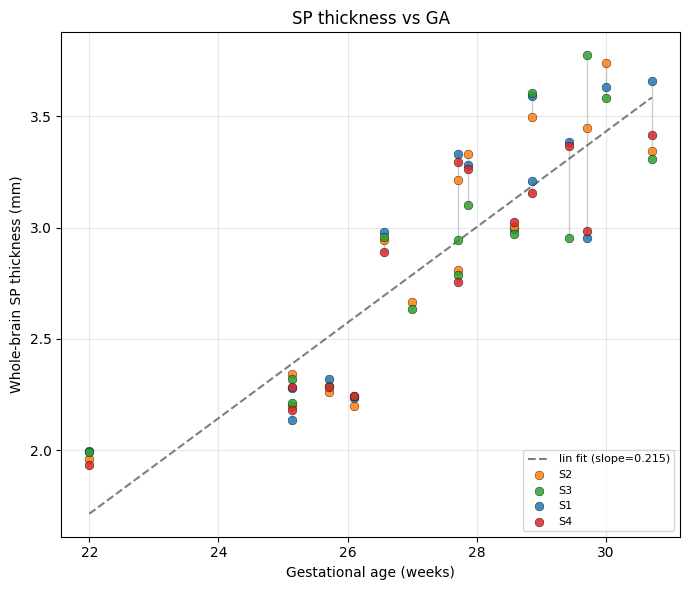

Pearson r (GA vs thickness) = +0.887


In [9]:
# Plot 1: thickness vs GA — points grouped per subject (vertical line connecting splits) and labeled by subject_id
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
fig, ax = plt.subplots(figsize=(7, 6))

# linear fit on all points
z = np.polyfit(df['GA'], df['wholebrain_thk_mean'], 1)
xs = np.linspace(df['GA'].min(), df['GA'].max(), 100)
ax.plot(xs, np.polyval(z, xs), 'k--', alpha=0.5, label=f'lin fit (slope={z[0]:.3f})')

# per subject: connect splits with a thin vertical line + label
seen_split_labels = set()
for sid, g in df.groupby('subject_id'):
    ga = g['GA'].iloc[0]
    ys = g['wholebrain_thk_mean'].values
    # vertical connector
    ax.plot([ga, ga], [ys.min(), ys.max()], color='grey', alpha=0.4, linewidth=1, zorder=1)
    # one dot per split (colored)
    for _, r in g.iterrows():
        lbl = r['split'] if r['split'] not in seen_split_labels else None
        seen_split_labels.add(r['split'])
        ax.scatter(ga, r['wholebrain_thk_mean'],
                   color=split_colors.get(r['split'], 'black'),
                   s=40, alpha=0.85, edgecolor='black', linewidth=0.3,
                   label=lbl, zorder=3)
    # # label with subject id, offset slightly to the right of the top dot
    # ax.annotate(sid, xy=(ga, ys.max()), xytext=(4, 4),
    #             textcoords='offset points', fontsize=7, alpha=0.85)

ax.set_xlabel('Gestational age (weeks)')
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('SP thickness vs GA')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('thickness_01_vs_ga.png', dpi=120)
plt.show()
r = df[['GA', 'wholebrain_thk_mean']].corr().iloc[0, 1]
print(f'Pearson r (GA vs thickness) = {r:+.3f}')

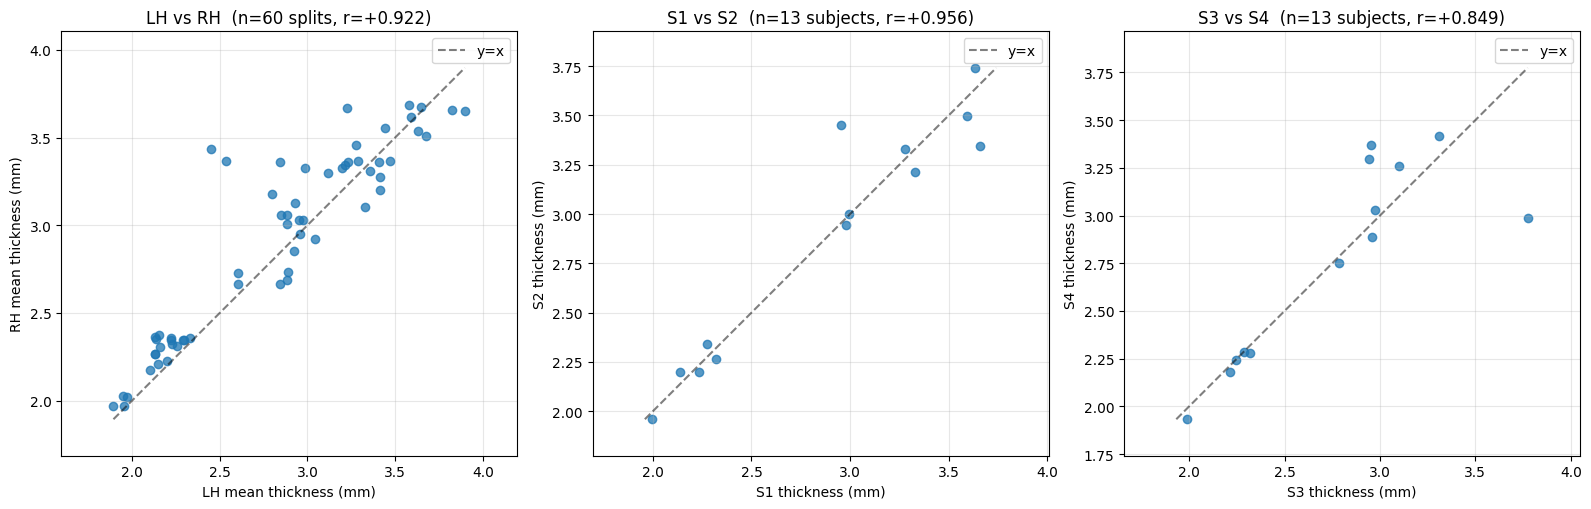

Mean |LH-RH| asymmetry = 0.163 mm
S1 vs S2: n=13, mean |Δ|=0.113 mm, max |Δ|=0.495 mm
S3 vs S4: n=13, mean |Δ|=0.162 mm, max |Δ|=0.788 mm


In [5]:
# Plot 2: agreement plots — LH vs RH (all rows), S1 vs S2 (per-subject pairs), S3 vs S4 (per-subject pairs).
# Split-pair plots use only subjects that have BOTH splits in the pair; report n comparisons.

def _agreement(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, alpha=0.75)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y=x')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

pivot = df.pivot_table(index='subject_id', columns='split',
                       values='wholebrain_thk_mean', aggfunc='first')

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# (a) LH vs RH — every subject/split row contributes
r_lhrh = df[['lh_thk_mean', 'rh_thk_mean']].corr().iloc[0, 1]
_agreement(axes[0], df['lh_thk_mean'], df['rh_thk_mean'],
           'LH mean thickness (mm)', 'RH mean thickness (mm)',
           f'LH vs RH  (n={len(df)} splits, r={r_lhrh:+.3f})')

# (b) S1 vs S2 — subjects with both
for ax, (a, b) in zip(axes[1:], [('S1', 'S2'), ('S3', 'S4')]):
    if a in pivot.columns and b in pivot.columns:
        pair = pivot[[a, b]].dropna()
        if len(pair) > 1:
            r_pair = pair.corr().iloc[0, 1]
            _agreement(ax, pair[a], pair[b],
                       f'{a} thickness (mm)', f'{b} thickness (mm)',
                       f'{a} vs {b}  (n={len(pair)} subjects, r={r_pair:+.3f})')
        else:
            ax.set_title(f'{a} vs {b}  (n={len(pair)} subjects — insufficient)')
    else:
        ax.set_title(f'{a} vs {b}  (no data)')

plt.tight_layout()
plt.savefig('thickness_02_lh_vs_rh.png', dpi=120)
plt.show()

print(f'Mean |LH-RH| asymmetry = {(df.lh_thk_mean - df.rh_thk_mean).abs().mean():.3f} mm')
for a, b in [('S1', 'S2'), ('S3', 'S4')]:
    pair = pivot[[a, b]].dropna()
    if len(pair):
        diff = (pair[a] - pair[b]).abs()
        print(f'{a} vs {b}: n={len(pair)}, mean |Δ|={diff.mean():.3f} mm, max |Δ|={diff.max():.3f} mm')

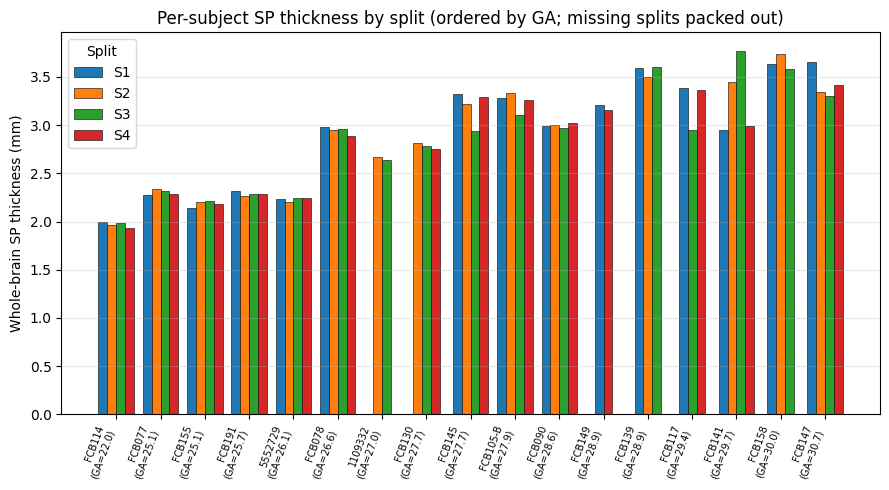

Subjects shown: 17
Splits-missing-per-subject distribution:
0    11
1     4
2     2


In [13]:
# Plot 3: bar plot ordered by GA — bars packed within each subject (no gap for missing splits)
splits = ['S1', 'S2', 'S3', 'S4']
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
subj_order = df.groupby('subject_id')['GA'].first().sort_values().index.tolist()
pivot = (df.pivot_table(index='subject_id', columns='split',
                        values='wholebrain_thk_mean', aggfunc='first')
           .reindex(subj_order))
ga_by_subj = df.groupby('subject_id')['GA'].first().reindex(subj_order)

# Fixed bar width — same regardless of how many splits a subject has.
# Within each subject, present splits are packed and the group is centered on x.
bar_w = 0.8 / len(splits)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(subj_order))

legend_seen = set()
for i, sid in enumerate(subj_order):
    present = [s for s in splits if s in pivot.columns and pd.notna(pivot.loc[sid, s])]
    if not present:
        continue
    group_w = bar_w * len(present)
    start = x[i] - group_w / 2 + bar_w / 2
    for k, s in enumerate(present):
        lbl = s if s not in legend_seen else None
        legend_seen.add(s)
        ax.bar(start + k * bar_w, pivot.loc[sid, s], width=bar_w,
               color=split_colors[s], edgecolor='black', linewidth=0.4, label=lbl)

ax.set_xticks(x)
ax.set_xticklabels([f"{sid}\n(GA={ga:.1f})" for sid, ga in zip(subj_order, ga_by_subj)],
                   rotation=70, ha='right', fontsize=7)
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('Per-subject SP thickness by split (ordered by GA; missing splits packed out)')
# legend with consistent S1..S4 ordering
handles, labels = ax.get_legend_handles_labels()
ordered = sorted(zip(labels, handles), key=lambda lh: splits.index(lh[0]))
ax.legend([h for _, h in ordered], [l for l, _ in ordered], title='Split', loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('thickness_03_bars_by_ga.png', dpi=120)
plt.show()
print(f'Subjects shown: {len(subj_order)}')
print('Splits-missing-per-subject distribution:')
print(pivot.isna().sum(axis=1).value_counts().sort_index().to_string())

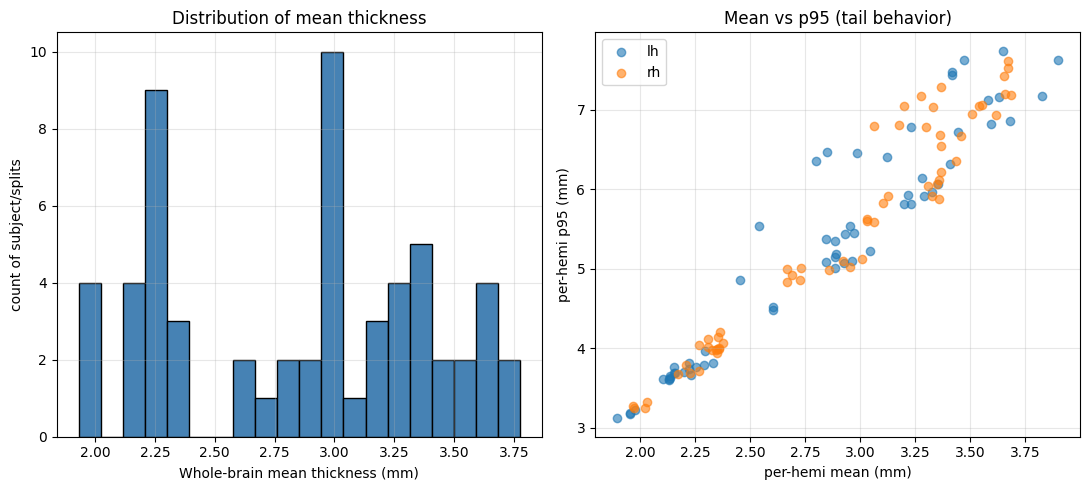

In [12]:
# Plot 4: distribution of per-vertex thickness statistics — median vs mean (should be close if symmetric)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].hist(df['wholebrain_thk_mean'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Whole-brain mean thickness (mm)')
axes[0].set_ylabel('count of subject/splits')
axes[0].set_title('Distribution of mean thickness')
axes[0].grid(alpha=0.3)
for hemi, color in [('lh', 'tab:blue'), ('rh', 'tab:orange')]:
    axes[1].scatter(df[f'{hemi}_thk_mean'], df[f'{hemi}_thk_p95'], alpha=0.6, label=hemi, color=color)
axes[1].set_xlabel('per-hemi mean (mm)')
axes[1].set_ylabel('per-hemi p95 (mm)')
axes[1].set_title('Mean vs p95 (tail behavior)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('thickness_04_distributions.png', dpi=120)
plt.show()